# Common

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys
from uncertainties import ufloat, unumpy

np.set_printoptions(linewidth=200)

In [63]:
# --- Класс для параметров стиля ---
@dataclass
class PlotParams:
    """Контейнер для параметров стиля отрисовки."""
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

# --- Класс-обертка для Matplotlib ---
class Plotter:
    """Класс для инкапсуляции всей логики построения графиков."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        """Инициализирует фигуру и оси, задает основные подписи."""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает точки."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает сплошную линию (обычно для аппроксимации)."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        """Отрисовывает экспериментальные точки с погрешностями."""
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker,
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """Настраивает финальное оформление, сохраняет и/или показывает график."""
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [64]:
def round_with_uncertainty(value: float, uncertainty: float) -> tuple[float, float]:
    """Округляет значение и погрешность по первой значащей цифре погрешности."""
    if uncertainty == 0 or not np.isfinite(uncertainty) or uncertainty < 1e-12:
        return value, uncertainty
    # Определяем порядок для округления на основе погрешности
    order = -int(np.floor(np.log10(abs(uncertainty))))
    return round(value, order), round(uncertainty, order)

def scale_to_scientific(val: float, sigm: float) -> tuple:
    """
    Рассчитывает компоненты для вывода в научном формате (мантисса, порядок и т.д.).
    Возвращает: (округленные val и sigm, мантиссы, порядок, отн. погрешность).
    """
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    
    # Расчет относительной погрешности
    if np.isclose(val_rounded, 0):
        varepsilon = float('inf')
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    # Определяем порядок числа для научной нотации
    if np.isclose(val_rounded, 0):
        scale_order = 0
    else:
        # Порядок определяется по абсолютному значению округленной величины
        scale_order = -int(np.floor(np.log10(abs(val_rounded))))

    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
    else:
        latex_value = val_rounded
        latex_uncertainty = sigm_rounded

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_parameter_report(val: float, sigm: float, parameter_name: str, unit: str = ""):
    """
    Печатает полный отчет по одному параметру.
    Включает сырые данные, округленные и LaTeX-формат с научной нотацией.
    """
    # Получаем все необходимые компоненты
    val_r, sigm_r, lat_val, lat_sigm, order, eps = scale_to_scientific(val, sigm)
    
    # Печатаем отчет
    print(f"------------ {parameter_name} ------------")
    print(f"Raw value     : {val} ± {sigm}")
    print(f"Rounded value : {val_r} ± {sigm_r}")
    
    # Формируем LaTeX строку с учетом порядка
    if order != 0:
        # f-строка с тройными скобками: {{}} для вывода фигурных скобок в LaTeX
        # и {} для подстановки переменной
        if order > 0:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{-{order}}}$ \\ {unit} $(\\varepsilon = {eps:.2f}\\%)$")
        else:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{{-order}}}$ \\ {unit}  $(\\varepsilon = {eps:.2f}\\%)$")
    else:
        print(f"LaTeX: $\\left( {val_r:.4f} \\pm {sigm_r:.4f} \\right)$ \\ {unit},  $(\\varepsilon = {eps:.2f}\\%)$")
    print()

def print_fit_summary(arguments: List[str], popt: np.ndarray, sigm_arr: np.ndarray):
    """
    Печатает сводку по всем результатам аппроксимации.
    """
    print("="*50)
    print("             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ")
    print("="*50)
    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_parameter_report(val, sigm, arg)


In [65]:
def load_data(filename: str):
    """Загружает данные из текстового файла."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

def calculate_errors(xdata: np.ndarray, ydata: np.ndarray, config: Dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    """
    Гибко вычисляет массивы погрешностей для x и y на основе конфигурационного словаря.
    """
    err_type = config.get('type')
    xerr, yerr = None, None # По умолчанию погрешностей нет

    if err_type == 'absolute':
        xerr = np.full_like(xdata, config.get('x_val', 0))
        yerr = np.full_like(ydata, config.get('y_val', 0))
    elif err_type == 'percent':
        xerr = config.get('x_val', 0) * xdata
        yerr = config.get('y_val', 0) * ydata
    elif err_type == 'custom':
        xerr = config.get('x_err_custom')
        yerr = config.get('y_err_custom')
        
    # Если какой-то из массивов не был создан, заменяем его на массив нулей
    if xerr is None:
        xerr = np.zeros_like(xdata)
    if yerr is None:
        yerr = np.zeros_like(ydata)
        
    return xerr, yerr

In [66]:
def load_data(filename: str, is_unc_x: bool = False, is_unc_y: bool = False):

    data = np.loadtxt(filename)

    if (is_unc_x and not is_unc_y) or (not is_unc_x and is_unc_y):
        return data[:, 0], data[:, 1], data[:, 2]
    if is_unc_x and is_unc_y:
        return data[:, 0], data[:, 1], data[:, 2], data[:, 3]
    else:
        return data[:, 0], data[:, 1]


In [67]:
phi_arr, N_arr, phi_err_arr, N_err_arr = load_data('data.txt', is_unc_x=True, is_unc_y=True)

phi_arr_u = unumpy.uarray(phi_arr, phi_err_arr)
N_arr_u = unumpy.uarray(N_arr, N_err_arr)                                                           

In [68]:
x_arr_u = 1 - unumpy.cos(phi_arr_u * np.pi / 180)
y_arr_u = 1 / N_arr_u

# Settings

In [69]:
# arguments = ['a']
# def func_ax(x, a):
#     return a * x

arguments = ['a', 'b']
def func_axpb(x, a, b):
    return a * x + b

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

In [70]:
func = func_axpb

# Changable parameters

In [71]:
# (0 --- np.inf)
error_config = \
{
    'type': 'absolute', 
    'x_val': unumpy.std_devs(x_arr_u), 
    'y_val': unumpy.std_devs(y_arr_u)
}

# # (0 --- 1)
# error_config = \
# {
#     'type': 'percent', 
#     'x_val': 0.05, 
#     'y_val': 0.1
# }

# # User errors
# error_config = \
# {
#     'type': 'custom', 
#     'x_val': np.full_like(I_data, 0.02), 
#     'y_val': error_N_net,
# }

# Run

In [72]:
# 2. Расчет погрешностей
x, y = unumpy.nominal_values(x_arr_u), unumpy.nominal_values(y_arr_u)

xerr, yerr = calculate_errors(x, y, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, x, y, sigma=unumpy.std_devs(y_arr_u))

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
a, b = popt

a_u = unumpy.uarray(a, np.sqrt(np.diag(pcov))[0])
b_u = unumpy.uarray(b, np.sqrt(np.diag(pcov))[1])

             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : 0.0014845204144661778 ± 2.9860443763075178e-05
Rounded value : 0.00148 ± 3e-05
LaTeX: $\left( 1.480 \pm 0.030 \right) \cdot 10^{-3}$ \  $(\varepsilon = 2.03\%)$

------------ b ------------
Raw value     : 0.001138895603050978 ± 9.052161815065063e-06
Rounded value : 0.001139 ± 9e-06
LaTeX: $\left( 1.139 \pm 0.009 \right) \cdot 10^{-3}$ \  $(\varepsilon = 0.79\%)$



In [78]:
print(a_u)

0.001485+/-0.000030


In [80]:
y_1_u = func(1, a_u, b_u)

E_yamma = 662  # keV

E_0 = E_yamma * 1 / (y_1_u / b_u - 1)

print(E_0)

508+/-11


In [74]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, markevery=markevery_i, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: example.pdf


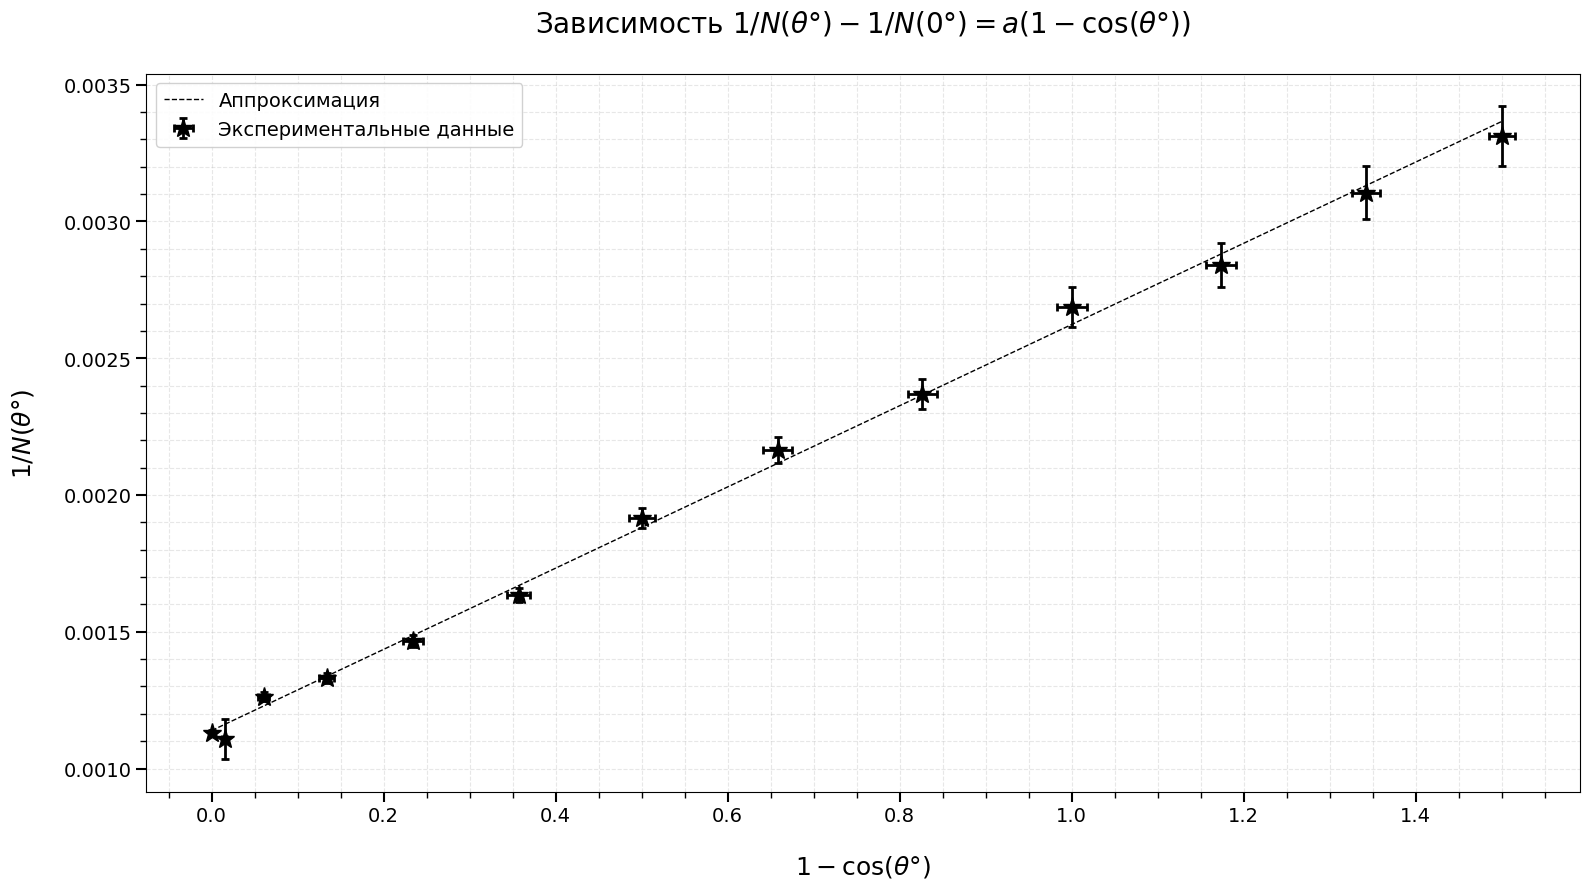

In [75]:
# --- 2. Построение графика ---
plotter = Plotter(
    title=r'Зависимость $1/N(\theta \degree) - 1/N(0 \degree) = a(1-\cos(\theta \degree))$',
    xlabel=r'$1-\cos(\theta \degree)$',
    ylabel=r'$1/N(\theta \degree)$'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(x, y, xerr=xerr, yerr=yerr, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
x_smooth = np.linspace(x.min(), x.max(), 500)
y_fit = func(x_smooth, *popt)

plotter.add_fit_line(x_smooth, y_fit, params=plot_args_dict['Fitted'])

# Финализируем и показываем график
plotter.finalize_and_show("example.pdf")


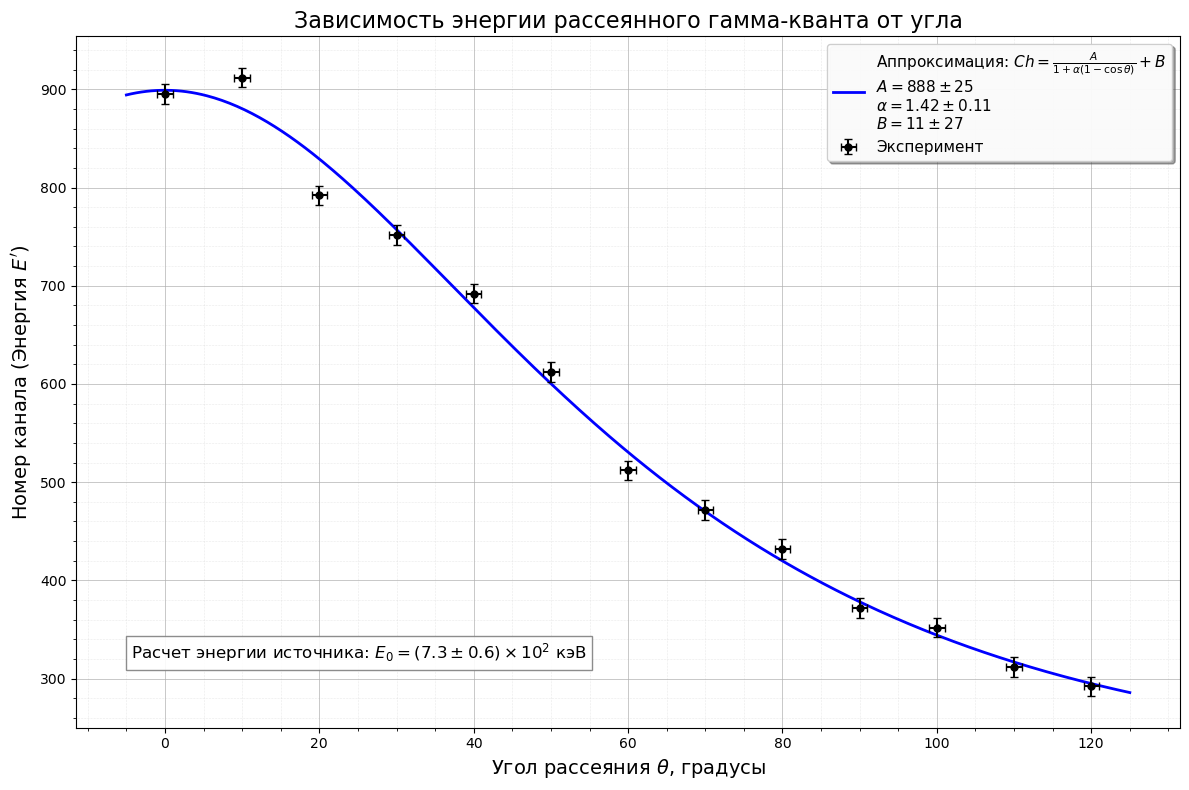

РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ (Channel vs Angle):
--------------------
--- Параметр формы alpha (E0/mc^2) ---
Raw:      1.4188696851299318 +/- 0.10791271034500954 
Rounded:  1.42+/-0.11 
Rel. Err: 7.61%
--- Амплитуда A (E0 в каналах) ---
Raw:      887.9889979414908 +/- 24.514982971374025 кан.
Rounded:  888+/-25 кан.
Rel. Err: 2.76%
--- Смещение нуля B ---
Raw:      11.097761241683163 +/- 26.67326941306712 кан.
Rounded:  11+/-27 кан.
Rel. Err: 240.35%
--------------------
Рассчитанная энергия источника E0: (7.3+/-0.6)e+02 кэВ
(Ожидается ~662 кэВ для Cs-137)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat, unumpy

# --- Вспомогательная функция для вывода (ОБЯЗАТЕЛЬНО) ---
def print_full_info(name, param_u, unit=""):
    """Выводит полную статистику по параметру ufloat"""
    val = param_u.n
    err = param_u.s
    rel_err = (err / abs(val)) * 100 if val != 0 else 0
    
    print(f"--- {name} ---")
    print(f"Raw:      {val} +/- {err} {unit}")
    print(f"Rounded:  {param_u} {unit}")
    print(f"Rel. Err: {rel_err:.2f}%")

# --- 1. Входные данные ---
# Углы рассеяния
theta_data = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120])
# Номера каналов (положения фотопиков)
channel_data = np.array([895, 912, 792, 752, 692, 612, 512, 472, 432, 372, 352, 312, 292])

# Погрешности
# Оценим погрешность определения максимума пика в +/- 10 каналов (типично для NaI(Tl))
y_err = np.full_like(channel_data, 10.0)
x_err = 1.0 

# --- 2. Модель Комптона (в шкале каналов) ---
# E' = E0 / (1 + alpha*(1 - cos(theta)))
# Ch = k * E' + Ch_offset
# Ch = (k * E0) / (1 + alpha*(1 - cos(theta))) + Ch_offset
# Обозначим: A = k*E0, B = Ch_offset

def compton_channel_model(theta_deg, A, alpha, B):
    theta = np.deg2rad(theta_deg)
    return A / (1 + alpha * (1 - np.cos(theta))) + B

# Начальное приближение
# A ~ 900 (канал при 0 градусов)
# alpha ~ 1.3 (для Cs-137)
# B ~ 0
p0 = [900, 1.3, 0]

popt, pcov = curve_fit(compton_channel_model, theta_data, channel_data, p0=p0, sigma=y_err, absolute_sigma=True, bounds=(0, np.inf))
perr = np.sqrt(np.diag(pcov))

# --- 3. Работа с uncertainties ---
A_u = ufloat(popt[0], perr[0])
alpha_u = ufloat(popt[1], perr[1])
B_u = ufloat(popt[2], perr[2])

# Расчет физической величины E0 (энергия источника)
# alpha = E0 / 511 кэВ => E0 = alpha * 511
E0_calc = alpha_u * 511.0

# --- 4. Построение графика ---
plt.figure(figsize=(12, 8))

# Точки эксперимента
plt.errorbar(theta_data, channel_data, xerr=x_err, yerr=y_err, fmt='ko', 
             label='Эксперимент', capsize=3, markersize=5, zorder=5)

# Аппроксимация
x_model = np.linspace(min(theta_data)-5, max(theta_data)+5, 400)
y_model = compton_channel_model(x_model, *popt)

# Легенда с формулой и параметрами
label_fit = (r'Аппроксимация: $Ch = \frac{A}{1 + \alpha(1-\cos\theta)} + B$' + '\n' +
             rf'$A = {A_u:L}$' + '\n' +
             rf'$\alpha = {alpha_u:L}$' + '\n' +
             rf'$B = {B_u:L}$')

plt.plot(x_model, y_model, 'b-', label=label_fit, linewidth=2, zorder=4)

# Доп. информация о рассчитанной энергии
plt.text(0.05, 0.1, rf'Расчет энергии источника: $E_0 = {E0_calc:L}$ кэВ', 
         transform=plt.gca().transAxes, fontsize=12, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'))

# Оформление
plt.xlabel(r'Угол рассеяния $\theta$, градусы', fontsize=14)
plt.ylabel(r'Номер канала (Энергия $E^\prime$)', fontsize=14)
plt.title(r'Зависимость энергии рассеянного гамма-кванта от угла', fontsize=16)

plt.minorticks_on()
plt.grid(which='major', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.5)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95, shadow=True)

plt.tight_layout()
plt.savefig("compton_energy_fit.pdf")
plt.show()

# --- 5. Вывод результатов ---
print("="*50)
print("РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ (Channel vs Angle):")
print("-" * 20)
print_full_info("Параметр формы alpha (E0/mc^2)", alpha_u, "")
print_full_info("Амплитуда A (E0 в каналах)", A_u, "кан.")
print_full_info("Смещение нуля B", B_u, "кан.")
print("-" * 20)
print(f"Рассчитанная энергия источника E0: {E0_calc} кэВ")
print("(Ожидается ~662 кэВ для Cs-137)")
print("="*50)